In [31]:
import os

os.environ["KERAS_BACKEND"] = "jax"

In [32]:
from pathlib import Path
import random

import jax
import grain.python as grain
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import keras

In [33]:
print(jax.devices())
print(jax.__version__)

[CudaDevice(id=0)]
0.10.0


In [34]:
print(keras.__version__)

3.14.0


In [35]:
keras.mixed_precision.set_global_policy("mixed_float16")

In [36]:
DATA_DIR = Path("data/oxford-iiit-pet")
IMAGES_DIR = DATA_DIR / "images"
LABELS_DIR = DATA_DIR / "annotations" / "trimaps"
LIST_FILE = DATA_DIR / "annotations" / "list.txt"

BATCH_SIZE = 128
TARGET_SIZE = (160, 160)
N_CLASSES = 3

In [37]:
stems = [
    line.split()[0]
    for line in LIST_FILE.read_text().splitlines()
    if line and not line.startswith("#")
]
stems = [
    s
    for s in stems
    if (IMAGES_DIR / f"{s}.jpg").exists() and (LABELS_DIR / f"{s}.png").exists()
]
stems.sort()

n = len(stems)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_stems = stems[:n_train]
val_stems = stems[n_train : n_train + n_val]
test_stems = stems[n_train + n_val :]

train_imgs = [IMAGES_DIR / f"{s}.jpg" for s in train_stems]
train_msks = [LABELS_DIR / f"{s}.png" for s in train_stems]
val_imgs = [IMAGES_DIR / f"{s}.jpg" for s in val_stems]
val_msks = [LABELS_DIR / f"{s}.png" for s in val_stems]
test_imgs = [IMAGES_DIR / f"{s}.jpg" for s in test_stems]
test_msks = [LABELS_DIR / f"{s}.png" for s in test_stems]

steps_train = len(train_imgs) // BATCH_SIZE
steps_val = len(val_imgs) // BATCH_SIZE

print(
    f"Total: {n}  |  Train: {len(train_imgs)}  |  Val: {len(val_imgs)}  |  Test: {len(test_imgs)}"
)
print(f"Steps - train: {steps_train}  val: {steps_val}")

Total: 7349  |  Train: 5144  |  Val: 1102  |  Test: 1103
Steps - train: 40  val: 8


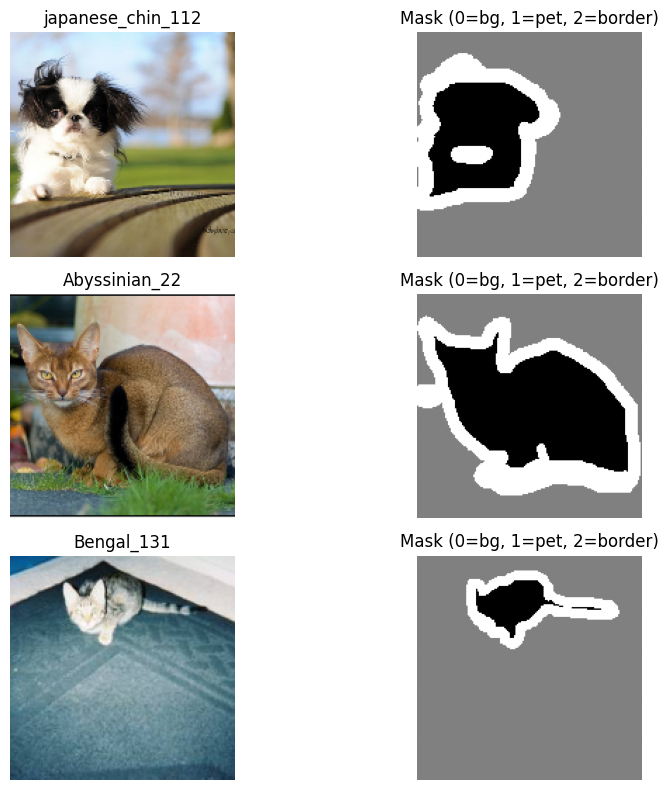

In [38]:
sample_stems = random.sample(train_stems, 3)

plt.figure(figsize=(10, 8))
for i, stem in enumerate(sample_stems):
    img = keras.preprocessing.image.smart_resize(
        np.array(
            Image.open(IMAGES_DIR / f"{stem}.jpg").convert("RGB"), dtype=np.float32
        )
        / 255.0,
        TARGET_SIZE,
    )
    msk_arr = np.array(Image.open(LABELS_DIR / f"{stem}.png"), dtype=np.int32)[
        ..., np.newaxis
    ]
    msk = (
        keras.preprocessing.image.smart_resize(
            msk_arr, TARGET_SIZE, interpolation="nearest"
        )[..., 0]
        - 1
    )

    ax = plt.subplot(3, 2, 2 * i + 1)
    ax.imshow((img * 255).astype("uint8"))
    ax.set_title(stem)
    ax.axis("off")

    ax = plt.subplot(3, 2, 2 * i + 2)
    ax.imshow(msk, cmap="gray")
    ax.set_title("Mask (0=bg, 1=pet, 2=border)")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [39]:
class PetDataSource(grain.RandomAccessDataSource):
    def __init__(self, img_paths, msk_paths):
        self.img_paths = img_paths
        self.msk_paths = msk_paths

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_arr = (
            np.array(Image.open(self.img_paths[idx]).convert("RGB"), dtype=np.float32)
            / 255.0
        )
        img = keras.preprocessing.image.smart_resize(img_arr, TARGET_SIZE)

        msk_arr = np.array(Image.open(self.msk_paths[idx]), dtype=np.int32)[
            ..., np.newaxis
        ]
        msk = keras.preprocessing.image.smart_resize(
            msk_arr, TARGET_SIZE, interpolation="nearest"
        )
        msk = (msk[..., 0] - 1).astype(np.int32)  # shape (H, W), values {0,1,2}
        return img, msk

    def __repr__(self):
        return f"PetDataSource(n={len(self)})"


def make_loader(img_paths, msk_paths, shuffle, num_epochs=None):
    source = PetDataSource(img_paths, msk_paths)
    sampler = grain.IndexSampler(
        num_records=len(source),
        shard_options=grain.NoSharding(),
        shuffle=shuffle,
        num_epochs=num_epochs,
        seed=42,
    )
    return grain.DataLoader(
        data_source=source,
        sampler=sampler,
        worker_count=0,
        operations=[grain.Batch(BATCH_SIZE, drop_remainder=True)],
    )


train_loader = make_loader(train_imgs, train_msks, shuffle=True)
val_loader = make_loader(val_imgs, val_msks, shuffle=False)
test_loader = make_loader(test_imgs, test_msks, shuffle=False, num_epochs=1)

x_batch, y_batch = next(iter(train_loader))
print(f"Images: {x_batch.shape}  dtype={x_batch.dtype}")
print(
    f"Masks:  {y_batch.shape}  dtype={y_batch.dtype}  unique={set(y_batch.ravel().tolist())}"
)

Images: (128, 160, 160, 3)  dtype=float32
Masks:  (128, 160, 160)  dtype=int32  unique={0, 1, 2}


In [40]:
def double_conv(x, filters):
    x = keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x


def encoder_block(x, filters):
    f = double_conv(x, filters)
    p = keras.layers.MaxPooling2D(2)(f)
    p = keras.layers.Dropout(0.2)(p)
    return f, p


def up_block(x, skip, filters):
    x = keras.layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
    x = keras.layers.concatenate([x, skip])
    x = keras.layers.Dropout(0.2)(x)
    return double_conv(x, filters)


def build_unet(input_shape=(160, 160, 3), n_classes=3):
    inputs = keras.Input(input_shape)
    f1, c1 = encoder_block(inputs, 16)
    f2, c2 = encoder_block(c1, 32)
    f3, c3 = encoder_block(c2, 64)
    b = double_conv(c3, 128)
    u1 = up_block(b, f3, 64)
    u2 = up_block(u1, f2, 32)
    u3 = up_block(u2, f1, 16)
    # dtype=float32: softmax + cross-entropy stay numerically stable
    outputs = keras.layers.Conv2D(
        n_classes, 1, padding="same", activation="softmax", dtype="float32"
    )(u3)
    return keras.Model(inputs, outputs)


model = build_unet()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 160, 160, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_30 (Conv2D)            │ (None, 160, 160, 16)      │             448 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_31 (Conv2D)            │ (None, 160, 160, 16)      │           2,320 │ conv2d_30[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_6               │ (None, 80, 80, 16)        │               0 │ conv2d_31[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_12 (Dropout)          │ (None, 80, 80, 16)        │               0 │ max_pooling2d_6[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_32 (Conv2D)            │ (None, 80, 80, 32)        │           4,640 │ dropout_12[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_33 (Conv2D)            │ (None, 80, 80, 32)        │           9,248 │ conv2d_32[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_7               │ (None, 40, 40, 32)        │               0 │ conv2d_33[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_13 (Dropout)          │ (None, 40, 40, 32)        │               0 │ max_pooling2d_7[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_34 (Conv2D)            │ (None, 40, 40, 64)        │          18,496 │ dropout_13[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_35 (Conv2D)            │ (None, 40, 40, 64)        │          36,928 │ conv2d_34[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_8               │ (None, 20, 20, 64)        │               0 │ conv2d_35[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_14 (Dropout)          │ (None, 20, 20, 64)        │               0 │ max_pooling2d_8[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_36 (Conv2D)            │ (None, 20, 20, 128)       │          73,856 │ dropout_14[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_37 (Conv2D)            │ (None, 20, 20, 128)       │         147,584 │ conv2d_36[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_6            │ (None, 40, 40, 64)        │          73,79

 Total params: 535,827 (2.04 MB)

 Trainable params: 535,827 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_ohe = keras.ops.one_hot(y_true, num_classes=N_CLASSES)
    y_pred_lbl = keras.ops.one_hot(keras.ops.argmax(y_pred, -1), num_classes=N_CLASSES)
    y_true_f = keras.ops.reshape(y_true_ohe, [-1, N_CLASSES])
    y_pred_f = keras.ops.reshape(y_pred_lbl, [-1, N_CLASSES])
    inter = keras.ops.sum(y_true_f * y_pred_f, axis=0)
    union = keras.ops.sum(y_true_f + y_pred_f, axis=0)
    return keras.ops.mean((2.0 * inter + smooth) / (union + smooth))


callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_unet.keras", monitor="val_loss", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
]

model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.IoU(
            num_classes=N_CLASSES,
            target_class_ids=list(range(N_CLASSES)),
            sparse_y_true=True,
            sparse_y_pred=False,
            name="mean_iou",
        ),
        dice_coef,
    ],
)

In [42]:
history = model.fit(
    train_loader,
    steps_per_epoch=steps_train,
    validation_data=val_loader,
    validation_steps=steps_val,
    epochs=100,
    callbacks=callbacks,
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 46s 850ms/step - accuracy: 0.4737 - dice_coef: 0.2743 - loss: 1.0046 - mean_iou: 0.2049 - val_accuracy: 0.5093 - val_dice_coef: 0.2638 - val_loss: 0.9561 - val_mean_iou: 0.1890
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 743ms/step - accuracy: 0.4980 - dice_coef: 0.3171 - loss: 0.9702 - mean_iou: 0.2326 - val_accuracy: 0.5343 - val_dice_coef: 0.3468 - val_loss: 0.9637 - val_mean_iou: 0.2454
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 813ms/step - accuracy: 0.5072 - dice_coef: 0.3405 - loss: 0.9774 - mean_iou: 0.2453 - val_accuracy: 0.5177 - val_dice_coef: 0.3649 - val_loss: 0.9510 - val_mean_iou: 0.2533
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 796ms/step - accuracy: 0.5266 - dice_coef: 0.3626 - loss: 0.9441 - mean_iou: 0.2612 - val_accuracy: 0.5640 - val_dice_coef: 0.3999 - val_loss: 0.9460 - val_mean_iou: 0.2877
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 746ms/step - accuracy: 0.5362 - dice_coef: 0.3729 - loss: 0.9380 - mean_iou: 0.2691 - val_acc

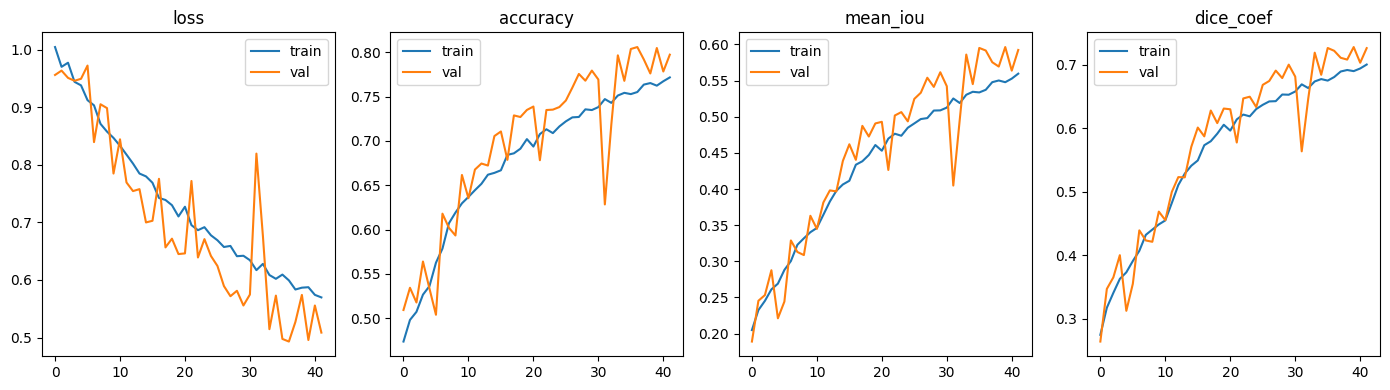

In [43]:
metrics = ["loss", "accuracy", "mean_iou", "dice_coef"]
plt.figure(figsize=(14, 4))
for i, m in enumerate(metrics):
    plt.subplot(1, 4, i + 1)
    plt.plot(history.history[m], label="train")
    plt.plot(history.history[f"val_{m}"], label="val")
    plt.title(m)
    plt.legend()
plt.tight_layout()
plt.show()

In [44]:
model = keras.models.load_model(
    "best_unet.keras",
    custom_objects={"dice_coef": dice_coef},
)

results = model.evaluate(
    make_loader(test_imgs, test_msks, shuffle=False, num_epochs=1),
    return_dict=True,
)
print(results)

steps_test = len(test_imgs) // BATCH_SIZE
smooth = 1e-6
class_dice = np.zeros(N_CLASSES, dtype=np.float32)
pixel_matches = 0
total_pixels = 0

for x_b, y_b in make_loader(test_imgs, test_msks, shuffle=False, num_epochs=1):
    y_pred_lbl = np.argmax(model.predict(x_b, verbose=0), axis=-1)

    pixel_matches += np.sum(y_pred_lbl == y_b)
    total_pixels += y_b.size

    for cls in range(N_CLASSES):
        y_t = (y_b == cls).astype(np.float32).ravel()
        y_p = (y_pred_lbl == cls).astype(np.float32).ravel()
        inter = np.sum(y_t * y_p)
        union = np.sum(y_t) + np.sum(y_p)
        class_dice[cls] += (2 * inter + smooth) / (union + smooth)

dice_scores = class_dice / steps_test
print(f"Pixel accuracy : {pixel_matches / total_pixels:.4f}")
print(f"Dice per class : {dice_scores}")
print(f"Mean Dice      : {dice_scores.mean():.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.8125 - dice_coef: 0.7258 - loss: 0.4790 - mean_iou: 0.5956
{'accuracy': 0.8124699592590332, 'dice_coef': 0.7257944345474243, 'loss': 0.47896406054496765, 'mean_iou': 0.5955972671508789}
Pixel accuracy : 0.8125
Dice per class : [0.8069267  0.8770625  0.49339372]
Mean Dice      : 0.7258


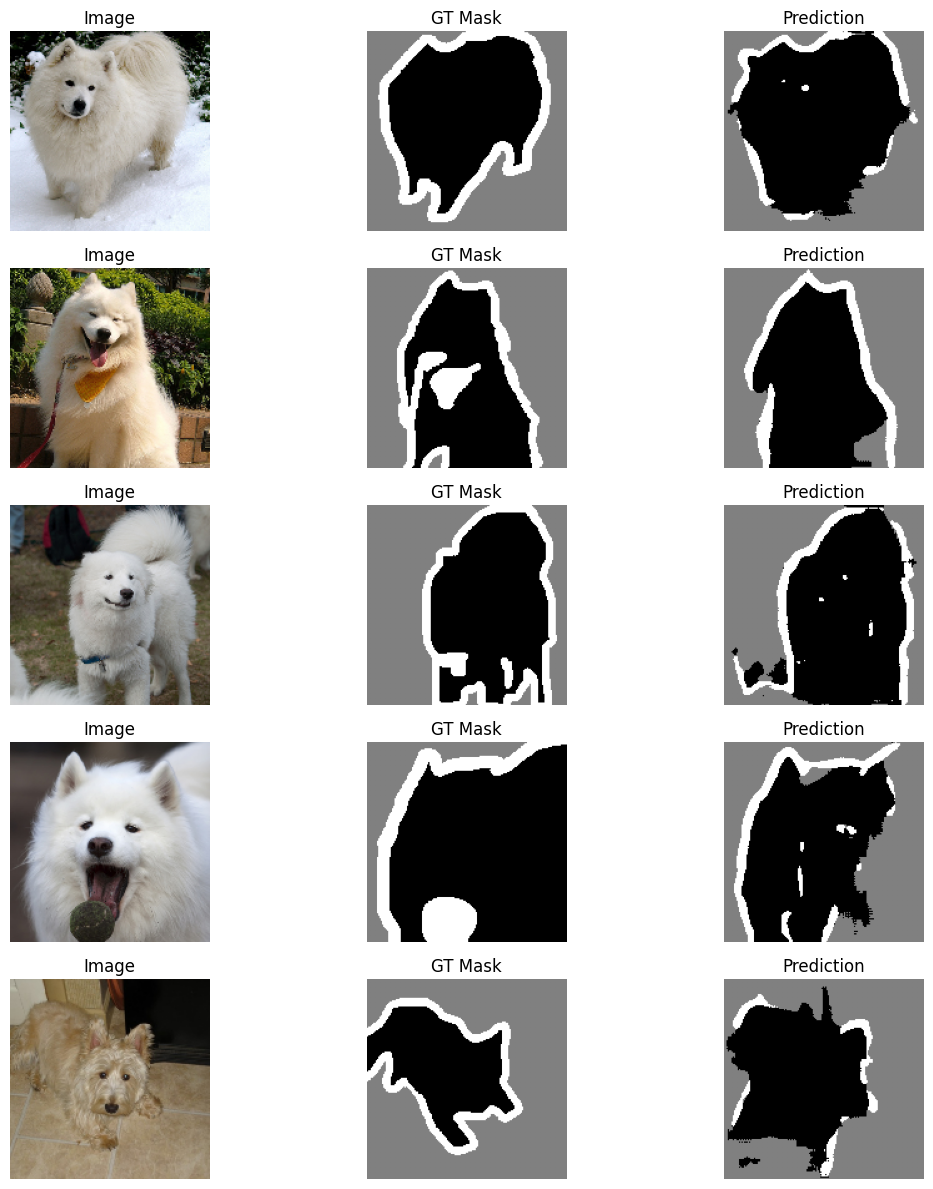

In [45]:
x_batch, y_batch = next(
    iter(make_loader(test_imgs, test_msks, shuffle=False, num_epochs=1))
)
indices = random.sample(range(BATCH_SIZE), 5)

plt.figure(figsize=(12, 12))
for i, idx in enumerate(indices):
    img = x_batch[idx]
    ygt = y_batch[idx]
    ypr = np.argmax(model.predict(img[np.newaxis, ...], verbose=0), axis=-1)[0]

    ax = plt.subplot(5, 3, 3 * i + 1)
    ax.imshow((img * 255).astype("uint8"))
    ax.set_title("Image")
    ax.axis("off")

    ax = plt.subplot(5, 3, 3 * i + 2)
    ax.imshow(ygt, cmap="gray")
    ax.set_title("GT Mask")
    ax.axis("off")

    ax = plt.subplot(5, 3, 3 * i + 3)
    ax.imshow(ypr, cmap="gray")
    ax.set_title("Prediction")
    ax.axis("off")

plt.tight_layout()
plt.show()